# 데이터 확인하기 #
## 0. 라이브러리 임포트 & 경로 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np



In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')

# 경로 설정 | 경로 문자열을 NFC 방식으로 통일
def normalize_path(path):
    return unicodedata.normalize('NFC', path).strip()

# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")

print("경로 확인:")
print(f"  TRAIN JSON : {TRAIN_JSON_PATH}")
print(f"  TEST  JSON : {TEST_JSON_PATH}")
print(f"  TRAIN IMG  : {TRAIN_IMG_DIR}")
print(f"  TEST  IMG  : {TEST_IMG_DIR}")

경로 확인:
  TRAIN JSON : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json
  TEST  JSON : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json
  TRAIN IMG  : /content/drive/MyDrive/data/초급_프로젝트/dataset/train_images
  TEST  IMG  : /content/drive/MyDrive/data/초급_프로젝트/dataset/test_images


## 1. 파일 존재 여부 및 기본 구조 확인

In [5]:
# 파일/폴더 존재 여부 체크
paths_to_check = {
    "TRAIN JSON": TRAIN_JSON_PATH,
    "TEST JSON" : TEST_JSON_PATH,
    "TRAIN IMG DIR": TRAIN_IMG_DIR,
    "TEST IMG DIR" : TEST_IMG_DIR,
}

for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "존재" if exists else "없음"
    print(f"{status} | {name}: {path}")

존재 | TRAIN JSON: /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json
존재 | TEST JSON: /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json
존재 | TRAIN IMG DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset/train_images
존재 | TEST IMG DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset/test_images


In [6]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for f in os.listdir(directory)
        if f.lower().endswith(IMG_EXTENSIONS)
    )

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}")
print(f"Test  이미지 수 : {n_test:,}")
print(f"합계            : {n_train + n_test:,}")

Train 이미지 수 : 1,489
Test  이미지 수 : 843
합계            : 2,332


In [7]:
# 샘플 데이터 구조 출력
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# JSON 최상위 키 확인
print("Train JSON 최상위 키:", list(train_json.keys()))
print("Test  JSON 최상위 키:", list(test_json.keys()))

Train JSON 최상위 키: ['images', 'annotations', 'categories']
Test  JSON 최상위 키: ['images', 'annotations', 'categories']


In [8]:
for split_name, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{split_name}]")
    print(f"  이미지 수          : {len(data['images'])}")
    print(f"  어노테이션 수      : {len(data['annotations'])}")
    print(f"  클래스(카테고리) 수 : {len(data['categories'])}")
    print()

[Train]
  이미지 수          : 1489
  어노테이션 수      : 4526
  클래스(카테고리) 수 : 73

[Test]
  이미지 수          : 843
  어노테이션 수      : 1129
  클래스(카테고리) 수 : 73



In [9]:
print("=== images 샘플 ===")
print(json.dumps(train_json['images'][0], ensure_ascii=False, indent=2))

print("\n=== annotations 샘플 ===")
print(json.dumps(train_json['annotations'][0], ensure_ascii=False, indent=2))

print("\n=== categories 샘플 (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

=== images 샘플 ===
{
  "file_name": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
  "width": 976,
  "height": 1280,
  "imgfile": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
  "drug_N": "K-001900",
  "drug_S": "정상알약",
  "back_color": "연회색 배경",
  "drug_dir": "앞면",
  "light_color": "주백색",
  "camera_la": 90,
  "camera_lo": 0,
  "size": 200,
  "dl_idx": "1899",
  "dl_mapping_code": "K-001900",
  "dl_name": "보령부스파정 5mg",
  "dl_name_en": "Buspar Tab. 5mg Boryung",
  "img_key": "http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg",
  "dl_material": "부스피론염산염",
  "dl_material_en": "Buspirone Hydrochloride",
  "dl_custom_shape": "정제, 저작정",
  "dl_company": "보령제약(주)",
  "dl_company_en": "Boryung",
  "di_company_mf": "",
  "di_company_mf_en": "",
  "item_seq": 198700706,
  "di_item_permit_date": "19870323",
  "di_class_no": "[01170]정신신경용제",
  "di_etc_otc_code": "전문의약품",
  "di_edi_code": "641901280,A09302381",
  "chart": "이약은 양면볼록한 장방형의 흰색정제이다",
  "drug_shape": "장방형",
  "thick":

## 3. 클래스 분포 분석

In [10]:
# category_id → 이름 매핑
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}

# 클래스별 어노테이션 수 집계
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"총 클래스 수: {len(df_class)}")
print(f"전체 어노테이션 수: {df_class['count'].sum():,}")
print(f"\n최다 클래스: {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 클래스: {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")
print(f"최대/최소 비율: {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n상위 10개 클래스:")
print(df_class.head(10).to_string(index=False))

총 클래스 수: 73
전체 어노테이션 수: 4,526

최다 클래스: 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 클래스: 브린텔릭스정 20mg (7개)
최대/최소 비율: 73.4x

상위 10개 클래스:
 category_id               name  count
        3482 기넥신에프정(은행엽엑스)(수출용)    514
        3350        일양하이트린정 2mg    240
        1899         보령부스파정 5mg    180
        2482        뮤테란캡슐 100mg    172
       16547        가바토파정 100mg    143
       16550      동아가바펜틴정 800mg    139
       35205       아토젯정 10/40mg    113
       29666           리바로정 4mg    111
       16231          리피토정 20mg    109
       36636       로수젯정10/5밀리그램    108


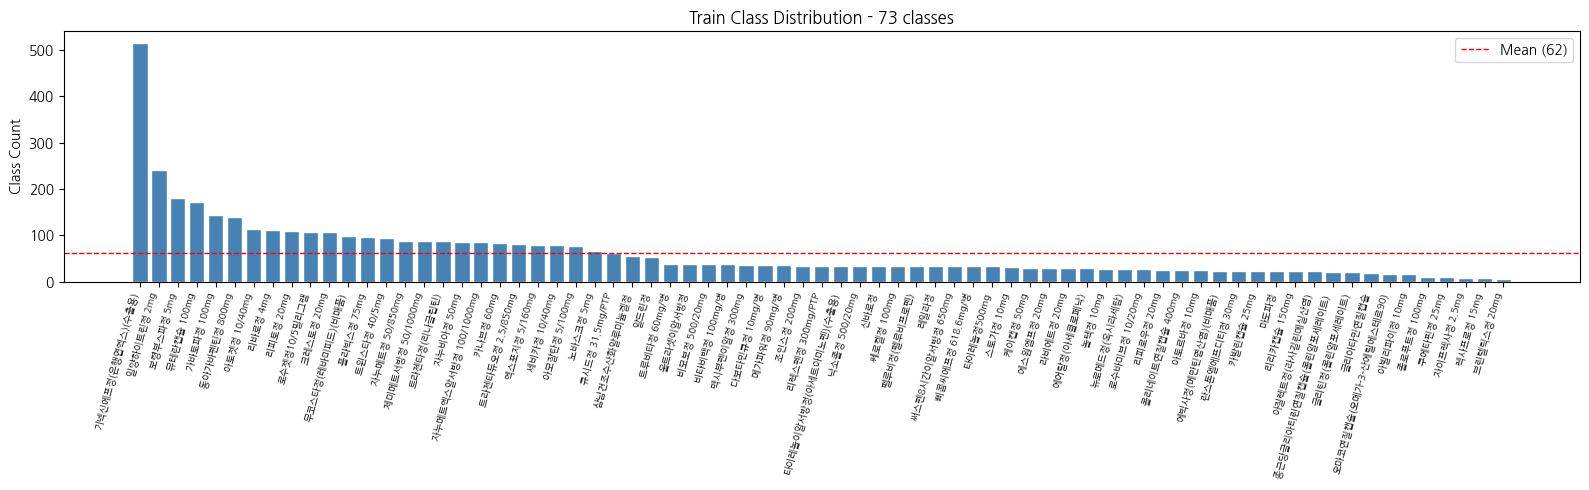

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # Colab 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(df_class)))
ax.set_xticklabels(df_class['name'], rotation=75, ha='right', fontsize=7)
ax.set_ylabel('Class Count')
ax.set_title('Train Class Distribution - 73 classes')
ax.axhline(df_class['count'].mean(), color='red', linestyle='--', linewidth=1, label=f"Mean ({df_class['count'].mean():.0f})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 이미지 해상도 분포 분석

In [12]:
widths, heights = [], []

for img_info in train_json['images']:
    widths.append(img_info['width'])
    heights.append(img_info['height'])

print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

# 해상도 조합별 빈도 확인
resolution_counter = Counter(zip(widths, heights))
print(f"\n해상도 종류 수: {len(resolution_counter)}")
print("\n상위 5개 해상도:")
for (w, h), cnt in resolution_counter.most_common(5):
    print(f"  {w}x{h} : {cnt}장")

Width  - min: 976, max: 976, mean: 976
Height - min: 1280, max: 1280, mean: 1280

해상도 종류 수: 1

상위 5개 해상도:
  976x1280 : 1489장


## 5. 바운딩 박스 분포 분석

In [13]:
# 이미지당 객체 수 분포
img_annot_count = Counter(annot['image_id'] for annot in train_json['annotations'])
obj_counts = list(img_annot_count.values())

print("이미지당 알약 수 분포:")
for k, v in sorted(Counter(obj_counts).items()):
    print(f"  {k}개 알약: {v:5d}장")

print(f"\n평균 객체 수: {np.mean(obj_counts):.2f}")
print(f"최대 객체 수: {max(obj_counts)}")

이미지당 알약 수 분포:
  1개 알약:    64장
  2개 알약:   302장
  3개 알약:   634장
  4개 알약:   489장

평균 객체 수: 3.04
최대 객체 수: 4


In [14]:
bbox_widths, bbox_heights, bbox_areas = [], [], []

for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    bbox_widths.append(w)
    bbox_heights.append(h)
    bbox_areas.append(w * h)

print(f"BBox 너비 - min: {min(bbox_widths):.0f}, max: {max(bbox_widths):.0f}, mean: {np.mean(bbox_widths):.0f}")
print(f"BBox 높이 - min: {min(bbox_heights):.0f}, max: {max(bbox_heights):.0f}, mean: {np.mean(bbox_heights):.0f}")
print(f"BBox 면적 - min: {min(bbox_areas):.0f}, max: {max(bbox_areas):.0f}, mean: {np.mean(bbox_areas):.0f}")

# 이미지 대비 BBox 크기 비율
img_w, img_h = 976, 1280
print(f"\n이미지 대비 BBox 평균 비율:")
print(f"  너비: {np.mean(bbox_widths)/img_w*100:.1f}%")
print(f"  높이: {np.mean(bbox_heights)/img_h*100:.1f}%")

BBox 너비 - min: 125, max: 529, mean: 259
BBox 높이 - min: 123, max: 669, mean: 289
BBox 면적 - min: 18492, max: 272435, mean: 78884

이미지 대비 BBox 평균 비율:
  너비: 26.6%
  높이: 22.6%


In [15]:
invalid_bboxes = []

for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    # 너비/높이가 0 이하이거나 이미지 밖으로 나간 경우
    if w <= 0 or h <= 0 or x < 0 or y < 0 or x + w > 976 or y + h > 1280:
        invalid_bboxes.append(annot['id'])

print(f"비정상 BBox 수: {len(invalid_bboxes)}")

비정상 BBox 수: 2


In [16]:
for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    if w <= 0 or h <= 0 or x < 0 or y < 0 or x + w > 976 or y + h > 1280:
        print(f"annotation id : {annot['id']}")
        print(f"image_id      : {annot['image_id']}")
        print(f"bbox          : {annot['bbox']}")
        print(f"x+w={x+w:.1f} (max 976), y+h={y+h:.1f} (max 1280)")
        print()

annotation id : 903
image_id      : 239
bbox          : [6567, 625, 311, 315]
x+w=6878.0 (max 976), y+h=940.0 (max 1280)

annotation id : 1157
image_id      : 310
bbox          : [653, 8889, 217, 217]
x+w=870.0 (max 976), y+h=9106.0 (max 1280)



## 6. 샘플 이미지 시각화 (바운딩 박스 포함)

--- 알약 1개 샘플 ---


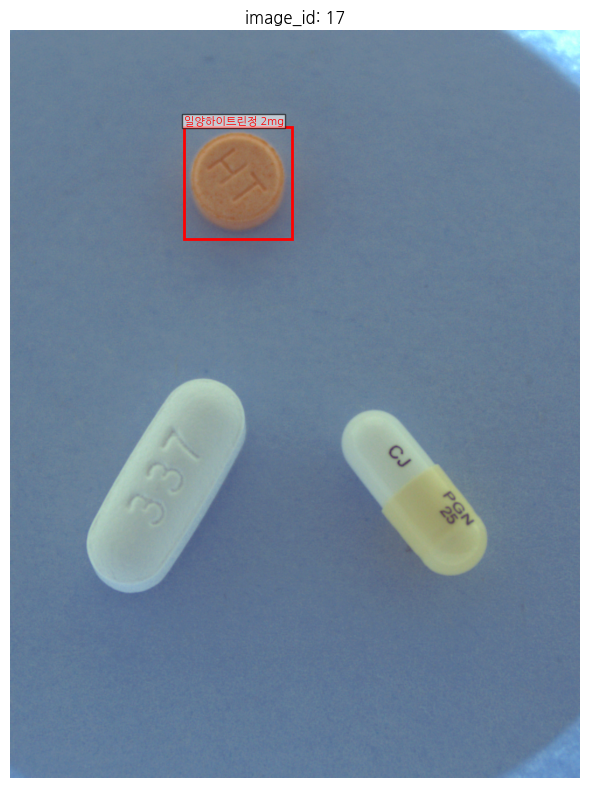

--- 알약 2개 샘플 ---


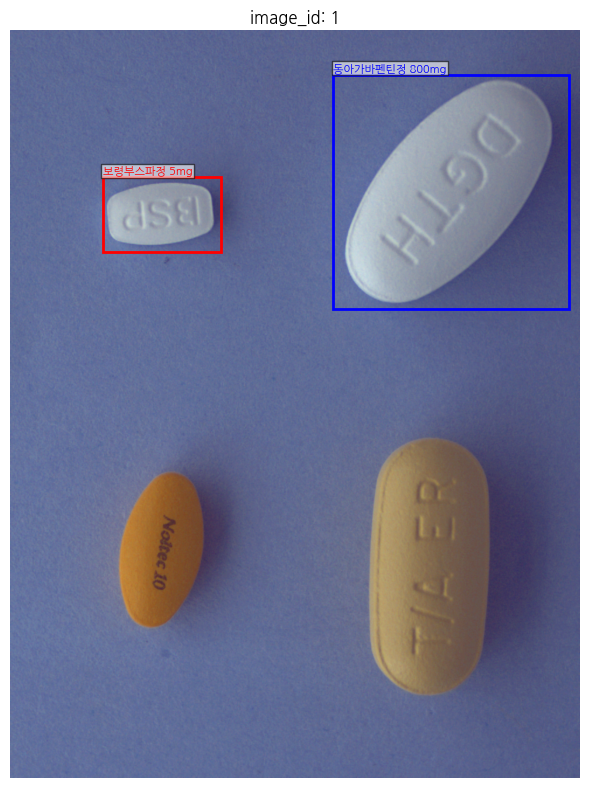

--- 알약 3개 샘플 ---


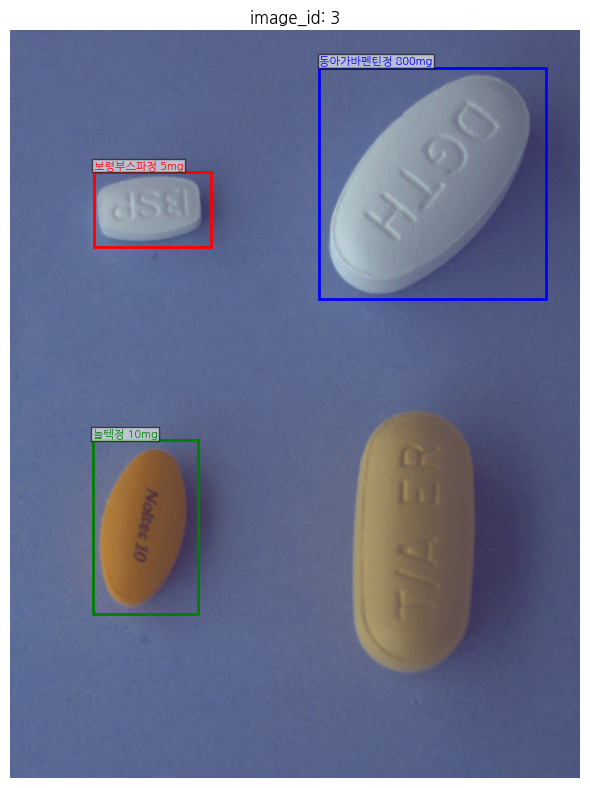

--- 알약 4개 샘플 ---


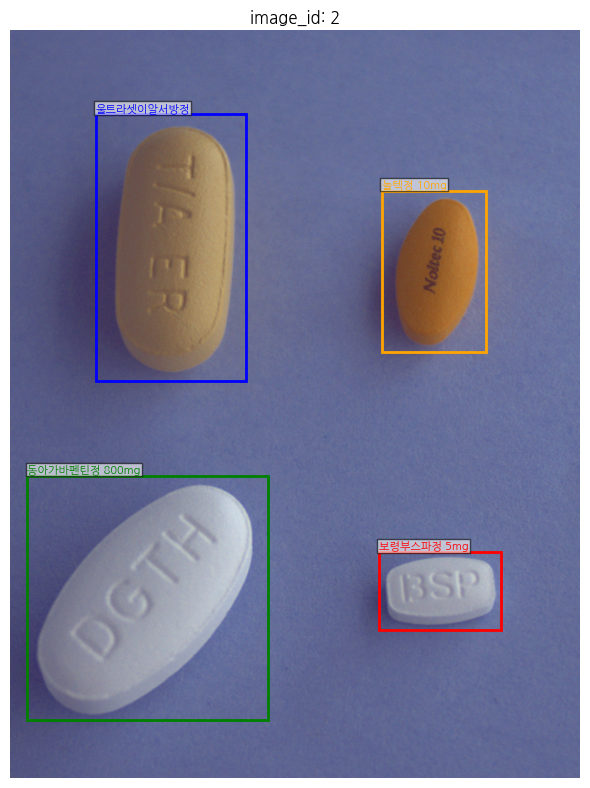

In [17]:
from collections import defaultdict
import matplotlib.patches as patches

id2filename = {img['id']: img['file_name'] for img in train_json['images']}

img2annots = defaultdict(list)
for annot in train_json['annotations']:
    img2annots[annot['image_id']].append(annot)

def visualize_sample(image_id):
    fname = id2filename.get(image_id)
    img_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(fname))
    img = Image.open(img_path).convert('RGB')

    fig, ax = plt.subplots(1, figsize=(6, 8))
    ax.imshow(img)

    colors = ['red', 'blue', 'green', 'orange']
    for i, annot in enumerate(img2annots[image_id]):
        x, y, w, h = annot['bbox']
        color = colors[i % len(colors)]
        rect = patches.Rectangle((x, y), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = id2name.get(annot['category_id'], '?')
        ax.text(x, y - 5, label, color=color, fontsize=8,
                bbox=dict(facecolor='white', alpha=0.6, pad=1))

    ax.set_title(f"image_id: {image_id}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 알약 수별로 샘플 1장씩 시각화
for n_obj in [1, 2, 3, 4]:
    sample_id = [img_id for img_id, cnt in img_annot_count.items() if cnt == n_obj][0]
    print(f"--- 알약 {n_obj}개 샘플 ---")
    visualize_sample(sample_id)

In [18]:
# 라벨링 안 된 알약이 얼마나 되는지 파악하기 위해
# 어노테이션 수 분포를 다시 한번 확인
print("어노테이션 기준 이미지당 알약 수:")
for k, v in sorted(Counter(obj_counts).items()):
    print(f"  라벨 {k}개: {v:5d}장 ({v/len(obj_counts)*100:.1f}%)")

어노테이션 기준 이미지당 알약 수:
  라벨 1개:    64장 (4.3%)
  라벨 2개:   302장 (20.3%)
  라벨 3개:   634장 (42.6%)
  라벨 4개:   489장 (32.8%)


📌 EDA 최종 요약
- Train 1,489장 / Test 843장 / 클래스 73개
- 해상도 976x1280으로 전체 통일
- 클래스 불균형 심함 (최대 514개 vs 최소 7개, 73.4배)
- 이미지당 알약 수: 평균 3.04개, 최대 4개
- BBox 크기: 이미지 대비 평균 26% (적당한 크기)
- 비정상 BBox 2개 (annotation id 903, 1157) → 전처리 시 제거
- 라벨 누락 알약 존재하나 의도된 설계로 판단

# 데이터 전처리 #

- 비정상 BBox 제거 — EDA에서 발견한 오류 2개 제거
- category_id 재매핑 — 1899, 27925 같은 불연속 id를 0, 1, 2… 로 변환. 모델이 연속된 정수 인덱스를 요구하기 때문
- 이미지 리사이즈 — 976x1280을 640x640으로 변환. BBox 좌표도 같은 비율로 함께 변환
- 정규화 — 픽셀값을 0~1 범위로 변환. 학습 안정성을 높여줘요
- Train/Val 분리 — 8:2 비율로 나누되 seed 고정해서 팀원 모두 동일한 결과
- YOLO 포맷 변환 — COCO의 [x, y, w, h]를 YOLO의 [center_x, center_y, w, h] 정규화 값으로 변환

## 1. 비정상 BBox 제거 ##

In [19]:
# 비정상 BBox 제거
invalid_ids = {903, 1157}  # EDA에서 발견한 annotation id

before = len(train_json['annotations'])
train_json['annotations'] = [
    annot for annot in train_json['annotations']
    if annot['id'] not in invalid_ids
]
after = len(train_json['annotations'])

print(f"제거 전 어노테이션 수: {before}")
print(f"제거 후 어노테이션 수: {after}")
print(f"제거된 수            : {before - after}")

제거 전 어노테이션 수: 4526
제거 후 어노테이션 수: 4524
제거된 수            : 2


## 2. 비정상 category_id 재매핑 ##

In [20]:
# category_id 재매핑 (불연속 id → 0부터 연속 정수)
original_ids = sorted([cat['id'] for cat in train_json['categories']])
id_remap = {old_id: new_id for new_id, old_id in enumerate(original_ids)}

# categories 업데이트
for cat in train_json['categories']:
    cat['id'] = id_remap[cat['id']]

# annotations 업데이트
for annot in train_json['annotations']:
    annot['category_id'] = id_remap[annot['category_id']]

# 확인
print(f"총 클래스 수: {len(id_remap)}")
print("\n재매핑 샘플 (앞 5개):")
for old, new in list(id_remap.items())[:5]:
    print(f"  {old:6d} → {new}")

총 클래스 수: 73

재매핑 샘플 (앞 5개):
    1899 → 0
    2482 → 1
    3350 → 2
    3482 → 3
    3543 → 4


In [22]:
# 양방향 매핑 저장
new_id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
new_id2old  = {new_id: old_id for old_id, new_id in id_remap.items()}
old_id2new  = id_remap  # 이미 만들어둔 것

print("새 id → 약 이름:")
for i in range(5):
    print(f"  {i} → {new_id2name[i]}")

print("\n새 id → 원래 id:")
for i in range(5):
    print(f"  {i} → {new_id2old[i]}")

새 id → 약 이름:
  0 → 보령부스파정 5mg
  1 → 뮤테란캡슐 100mg
  2 → 일양하이트린정 2mg
  3 → 기넥신에프정(은행엽엑스)(수출용)
  4 → 무코스타정(레바미피드)(비매품)

새 id → 원래 id:
  0 → 1899
  1 → 2482
  2 → 3350
  3 → 3482
  4 → 3543


category_id가 클래스는 73개인데, 넘버링은 수천자리 수로 등록되어있다. 
- 넘버링을 다시 지정해 모델 학습 과정에서 넘버링때문에 생기는 문제를 방지한다.
- 기존 넘버링이 약의 고유 넘버링일 수 있으므로 기존 데이터 또한 함께 보관한다.

## 3. 리사이징 ##

기존 976  X 1280크기의 이미지의 사이즈를 학습하기 좋게 640*640데이터로 가공한다.
- 기존 직사각형의 이미지를 정사각형으로 바꾸기만 한다면 비율이 틀어질 수 있다.
- 기존 비율은 유지시키고, padding을 통해 정사각형 형식에 맞춘다.

In [23]:
from PIL import Image, ImageOps
import os

def letterbox(image, target_size=640, fill_color=(114, 114, 114)):
    """
    비율을 유지하며 target_size x target_size 로 변환
    빈 공간은 fill_color 로 채움 (YOLO 기본값: 회색 114)
    반환값: 패딩된 이미지, (scale, pad_w, pad_h)
    """
    orig_w, orig_h = image.size
    scale = target_size / max(orig_w, orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    image = image.resize((new_w, new_h), Image.BILINEAR)

    # 좌우/상하 패딩 계산
    pad_w = (target_size - new_w) // 2
    pad_h = (target_size - new_h) // 2

    image = ImageOps.expand(image, (pad_w, pad_h, target_size - new_w - pad_w, target_size - new_h - pad_h), fill=fill_color)

    return image, (scale, pad_w, pad_h)

def transform_bbox(bbox, scale, pad_w, pad_h):
    """
    원본 BBox 좌표를 letterbox 변환에 맞게 조정
    bbox: [x, y, w, h] (COCO 포맷)
    """
    x, y, w, h = bbox
    x = x * scale + pad_w
    y = y * scale + pad_h
    w = w * scale
    h = h * scale
    return [x, y, w, h]

# 샘플 1장으로 확인
sample_img_info = train_json['images'][0]
sample_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(sample_img_info['file_name']))

orig_img = Image.open(sample_path).convert('RGB')
resized_img, (scale, pad_w, pad_h) = letterbox(orig_img)

print(f"원본 크기  : {orig_img.size}")
print(f"변환 후 크기: {resized_img.size}")
print(f"scale={scale:.4f}, pad_w={pad_w}, pad_h={pad_h}")

원본 크기  : (976, 1280)
변환 후 크기: (640, 640)
scale=0.5000, pad_w=76, pad_h=0


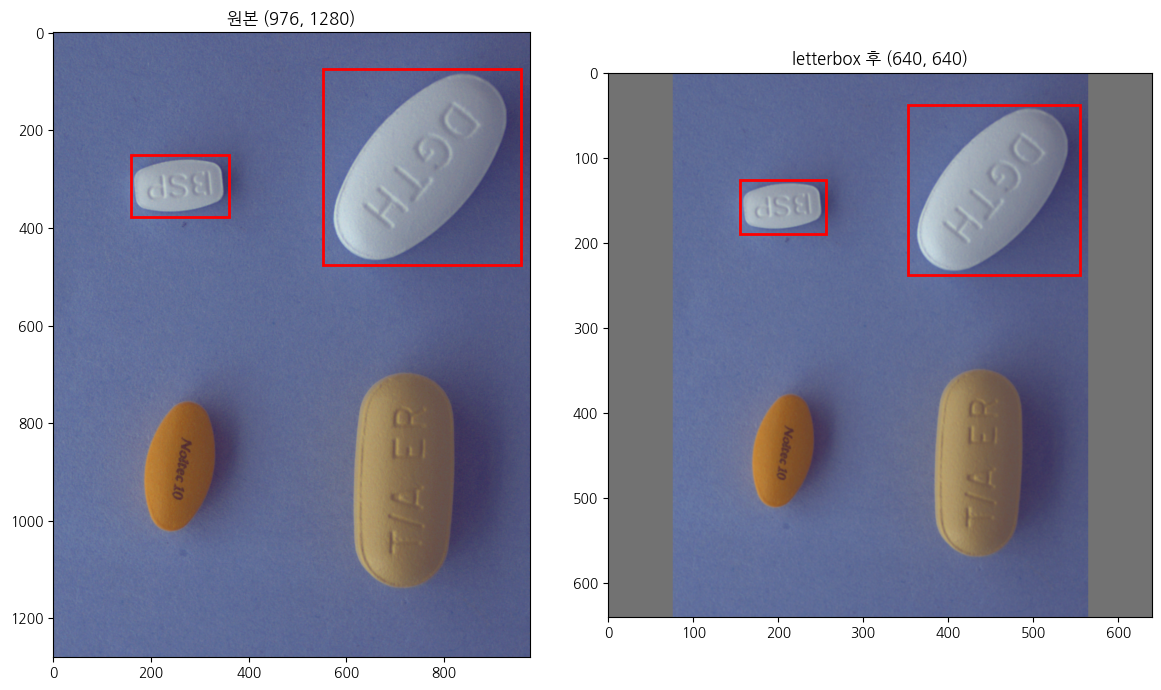

In [24]:
import matplotlib.patches as patches

sample_annots = [a for a in train_json['annotations'] if a['image_id'] == sample_img_info['id']]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# 원본
axes[0].imshow(orig_img)
axes[0].set_title(f"원본 {orig_img.size}")
for annot in sample_annots:
    x, y, w, h = annot['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)

# letterbox 변환 후
axes[1].imshow(resized_img)
axes[1].set_title(f"letterbox 후 {resized_img.size}")
for annot in sample_annots:
    x, y, w, h = transform_bbox(annot['bbox'], scale, pad_w, pad_h)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)

plt.tight_layout()
plt.show()

In [25]:
import os

PROCESSED_IMG_DIR = os.path.join(extract_path, "processed_images")
os.makedirs(PROCESSED_IMG_DIR, exist_ok=True)

# 전체 이미지에 letterbox 적용 후 저장
scale_info = {}  # image_id → (scale, pad_w, pad_h) 저장

for img_info in train_json['images']:
    img_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(img_info['file_name']))
    save_path = os.path.join(PROCESSED_IMG_DIR, os.path.basename(img_info['file_name']))

    img = Image.open(img_path).convert('RGB')
    resized, (scale, pad_w, pad_h) = letterbox(img)
    resized.save(save_path)

    scale_info[img_info['id']] = (scale, pad_w, pad_h)

print(f"저장 완료: {len(scale_info)}장 → {PROCESSED_IMG_DIR}")

저장 완료: 1489장 → /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_images


In [26]:
# 어노테이션 BBox도 letterbox 변환에 맞게 업데이트
for annot in train_json['annotations']:
    img_id = annot['image_id']
    if img_id not in scale_info:
        continue
    scale, pad_w, pad_h = scale_info[img_id]
    annot['bbox'] = transform_bbox(annot['bbox'], scale, pad_w, pad_h)

# 확인 - 샘플 3개 출력
print("변환된 BBox 샘플:")
for annot in train_json['annotations'][:3]:
    print(f"  annotation id {annot['id']}: {[round(v, 2) for v in annot['bbox']]}")

변환된 BBox 샘플:
  annotation id 1: [155.0, 125.5, 101.0, 63.5]
  annotation id 2: [391.5, 446.5, 105.0, 66.5]
  annotation id 3: [147.5, 121.0, 100.0, 64.0]


## 4. Train/Val 분리 ##
- Train / Val 각각 8:2비율로 데이터를 나눈다.
- 데이터가 1개처럼 작은 데이터는 임의로 Train에 배정한다.

In [28]:
from sklearn.model_selection import train_test_split

# 클래스별 이미지 수 확인
class_img_count = Counter(img_labels)

# 샘플 1개짜리 클래스에 속한 이미지 → 강제로 Train 배정
rare_ids = [
    img_id for img_id, label in zip(all_img_ids, img_labels)
    if class_img_count[label] < 2
]

# 나머지 이미지만 stratified split
normal_ids = [img_id for img_id in all_img_ids if img_id not in set(rare_ids)]
normal_labels = [
    Counter(img2cats[img_id]).most_common(1)[0][0] for img_id in normal_ids
]

train_normal_ids, val_ids = train_test_split(
    normal_ids,
    test_size=0.2,
    random_state=42,
    stratify=normal_labels
)

train_ids = train_normal_ids + rare_ids

print(f"희귀 클래스 강제 Train 배정: {len(rare_ids)}장")
print(f"Train : {len(train_ids)}장")
print(f"Val   : {len(val_ids)}장")
print(f"비율   : {len(train_ids)/len(all_img_ids)*100:.1f} : {len(val_ids)/len(all_img_ids)*100:.1f}")

희귀 클래스 강제 Train 배정: 2장
Train : 1191장
Val   : 298장
비율   : 80.0 : 20.0


 데이터 전처리 완료 요약
===============================================
[원본 데이터]
- Train 이미지  : 1,489장
- Test 이미지   : 843장
- 클래스 수     : 73개
- 해상도        : 976x1280 (전체 동일)

[전처리 과정]

1. 비정상 BBox 제거
   - annotation id 903 (x좌표 6567 이상)
   - annotation id 1157 (y좌표 8889 이상)
   - 4526개 → 4524개

2. category_id 재매핑
   - 불연속 id (1899, 27925 ...) → 0~72 연속 정수
   - 양방향 매핑 저장
     · new_id2name : 예측 결과 → 약 이름
     · new_id2old  : 예측 결과 → 원래 의약품 코드
     · old_id2new  : 원래 코드 → 새 id

3. 이미지 letterbox 리사이즈
   - 976x1280 → 640x640 (비율 유지)
   - 좌우 패딩 76px (회색 114, 114, 114)
   - 저장 위치: processed_images/
   - BBox 좌표 동시 변환 (scale=0.5, pad_w=76, pad_h=0)

4. Train / Val 분리
   - 희귀 클래스(샘플 1개) 2장 → 강제 Train 배정
   - 나머지 stratified split (seed=42)
   - Train 1,191장 / Val 298장 (80:20)

[보류 → DataLoader에서 처리 예정]
- 정규화        : 픽셀값 0~1 변환
- 밝기/색상 보정 : 화질 개선, 조명 차이 대응
- 데이터 증강   : Flip, Rotate, Color Jitter 등
  → 랜덤 적용으로 모델 일반화 성능 향상 목적
  → 매 epoch마다 다양한 변환 적용

[보류 → 모델 확정 후 진행 예정]
- YOLO 포맷 변환 : 모델에 맞는 포맷으로 변환
